In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression  # Simple linear model
from sklearn.ensemble import RandomForestRegressor  # More complex, handles non-linearity
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # For scaling and encoding
from sklearn.compose import ColumnTransformer  # To apply transforms selectively

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# loading the dataset
df = pd.read_csv('/content/student_data.csv')

In [ ]:
# basic stats
df.describe()

,Study_Hours,Attendance_Percent,Previous_Score,Final_Score
count,100.000000,100.000000,100.000000,100.000000
mean,4.844230,84.815790,70.588465,9.538745
std,1.362253,8.674872,15.285722,5.891350
min,1.070382,65.812288,21.380990,0.000000
25%,4.098641,76.943395,60.168347,5.112403
50%,4.809566,85.841072,71.465436,9.784773
75%,5.608928,90.381704,80.566562,12.786038
max,7.778417,100.000000,100.000000,24.412389


In [ ]:
# check for missing values
df.isnull().sum()

,0
Study_Hours,0
Attendance_Percent,0
Previous_Score,0
Extracurricular,0
Final_Score,0


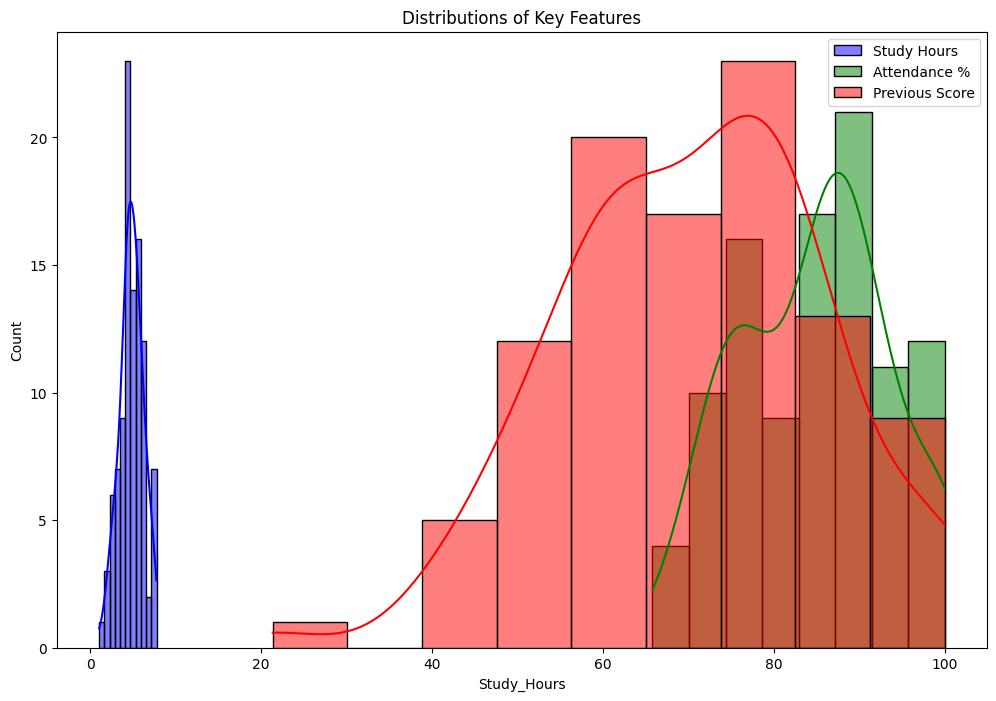

In [ ]:
# visualizing distributions
plt.figure(figsize=(12, 8))
sns.histplot(df['Study_Hours'], kde=True, color='blue', label='Study Hours')
sns.histplot(df['Attendance_Percent'], kde=True, color='green', label='Attendance %')
sns.histplot(df['Previous_Score'], kde=True, color='red', label='Previous Score')
plt.title('Distributions of Key Features')
plt.legend()
plt.show()

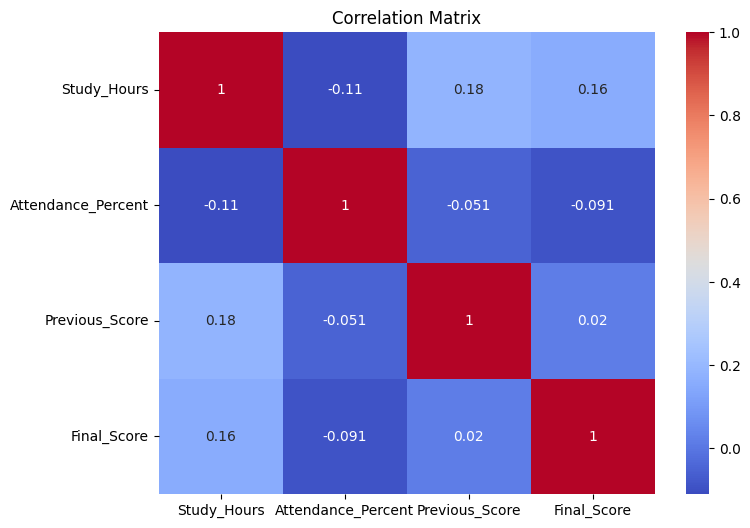

In [ ]:
# correlation heatmap showing relationships between numerical variables
numerical_df = df.select_dtypes(include=[np.number])  # Filter numerical columns
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

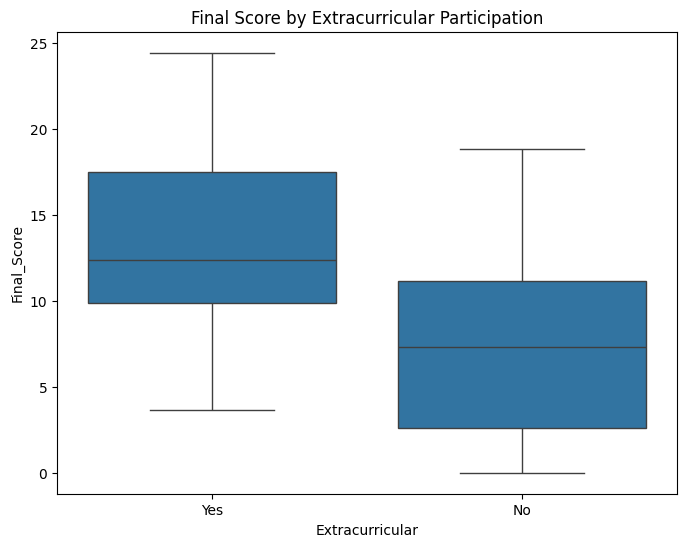

In [ ]:
# Boxplot for categorical impact
plt.figure(figsize=(8, 6))
sns.boxplot(x='Extracurricular', y='Final_Score', data=df)
plt.title('Final Score by Extracurricular Participation')
plt.show()

In [ ]:
# Data Preprocessing
# Separate features (X) and target (y)
X = df.drop('Final_Score', axis=1)  # All columns except target
y = df['Final_Score']

# Identify categorical and numerical columns
categorical_cols = ['Extracurricular']
numerical_cols = ['Study_Hours', 'Attendance_Percent', 'Previous_Score']

# Preprocessor: Scaling nums (mean=0, std=1), One-hot encode cats
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)  # drop='first' avoids multicollinearity
    ])

# Applying preprocessing
X_processed = preprocessor.fit_transform(X)

# Spliting into train (80%) and test (20%) sets—stratify not needed for regression
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Training set shape: (80, 4), Test set shape: (20, 4)


In [ ]:
# Linear Regression: Assumes linear relationships
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  # Train on train data

LinearRegression()

In [ ]:
# Predict on test
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# Evaluate: RMSE (error in score units), R2 (explained variance, 1=perfect)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression - RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}")

Linear Regression - RMSE: 5.40, R2: 0.23


In [ ]:
# Random Forest: Ensemble of trees, better for complex data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {rmse_rf:.2f}, R2: {r2_rf:.2f}")

Random Forest - RMSE: 5.79, R2: 0.11


In [ ]:
# Making predictions for new students
def predict_performance(model, preprocessor, study_hours, attendance_percent, previous_score, extracurricular):
    # Create a DataFrame for new data
    new_data = pd.DataFrame({
        'Study_Hours': [study_hours],
        'Attendance_Percent': [attendance_percent],
        'Previous_Score': [previous_score],
        'Extracurricular': [extracurricular]
    })
    # Preprocess
    new_processed = preprocessor.transform(new_data)
    # Predict
    prediction = model.predict(new_processed)[0]
    return f"Predicted Final Score: {prediction:.2f}"

# Example usage with best model (assuming RF is better)
print(predict_performance(rf_model, preprocessor, 6, 90, 75, 'Yes'))

Predicted Final Score: 12.51
